In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV files
file_path1 = "./esa_cci_class_area.csv"
file_path2 = "./glc_fcs30_class_area.csv"
df1 = pd.read_csv(file_path1, delimiter=';', decimal=',')
df2 = pd.read_csv(file_path2, delimiter=';', decimal=',')

# Convert area columns from m² to km²
df1.iloc[:, 2:] = df1.iloc[:, 2:] / 1_000_000
df2.iloc[:, 2:] = df2.iloc[:, 2:] / 1_000_000

/var/folders/s0/9nvdkxfx2y9f04nct7n3l8c40000gn/T/ipykernel_2689/3995903454.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      30900.42
1     191757.24
2     138997.44
3      24090.84
4        880.47
5       8995.41
6      15710.85
7        757.62
8       5342.31
9      49139.73
10     24444.90
11      4826.43
12     53622.18
13    144377.91
14    190489.77
15     54770.31
16        28.89
17       501.21
18       261.90
19        13.41
20         0.00
21         0.00
22         0.00
23         0.00
24      2054.52
25     16448.31
26      2493.81
27      2645.82
28      1672.65
29      8183.52
30      2761.92
31      2283.12
32     54189.99
33     98632.71
34    117916.65
35    176288.40
36         0.00
37      3087.54
38         0.00
39         0.00
Name: 1992, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.iloc[:, 2:] = df1.iloc[:, 2:] / 1_000_0

In [3]:
# Retrieve all unique land cover classes from the dataframe
class_names = df1['Land cover class'].unique()
class_names

array(['Forest', 'Shrubland', 'Grassland', 'Cropland', 'Wetland',
       'Lichens & Mosses', 'Bareland', 'Built-up', 'Water', 'Ice/Snow'],
      dtype=object)

#### PLOT GLOBAL STATISTICS FOR A SINGLE CLASS

In [4]:
def plot_land_cover_changes_compare(class_name, df1, df2, start_year=1992, end_year=2022, label1="Dataset 1", label2="Dataset 2"):
    # Define a color ramp (mapping of each class to a specific color)
    color_map = {
        'Shrubland': '#8b4513',
        'Grassland': '#32cd32',
        'Cropland': '#ffd700',
        'Wetland': '#4682b4',
        'Lichens and mosses': '#a9cda9',
        'Bareland': '#c2b280',
        'Built-up': '#808080',
        'Water': '#1e90ff',
        'Permanent ice and Snow': '#b0c4de',
        'Forest': '#006400',
        'No data': '#ffffff'
    }

    # Ensure that the years in the DataFrames match the provided range
    years1 = df1.columns[2:].astype(int)
    years2 = df2.columns[2:].astype(int)
    common_years = sorted(set(years1).intersection(set(years2)))
    common_years = [year for year in common_years if start_year <= year <= end_year]
    
    if len(common_years) == 0:
        print("No overlapping years in the provided range.")
        return

    # Find the row for the class_name in both datasets
    row1 = df1[df1['Land cover class'] == class_name]
    row2 = df2[df2['Land cover class'] == class_name]
    if row1.empty or row2.empty:
        print(f"Class '{class_name}' not found in one or both datasets.")
        return

    # Extract area values for both datasets
    area1 = row1.iloc[0, 2:].values
    area2 = row2.iloc[0, 2:].values
    year_idx1 = years1.get_indexer_for(common_years)
    year_idx2 = years2.get_indexer_for(common_years)
    
    selected_area1 = area1[year_idx1]
    selected_area2 = area2[year_idx2]

    # Calculate yearly differences, cumulative gains, and cumulative losses for both datasets
    yearly_diff1 = np.diff(selected_area1)
    yearly_diff2 = np.diff(selected_area2)
    cumulative_gain1 = np.sum(np.where(yearly_diff1 > 0, yearly_diff1, 0))
    cumulative_loss1 = np.sum(np.where(yearly_diff1 < 0, -yearly_diff1, 0))
    cumulative_gain2 = np.sum(np.where(yearly_diff2 > 0, yearly_diff2, 0))
    cumulative_loss2 = np.sum(np.where(yearly_diff2 < 0, -yearly_diff2, 0))
    
    cumulative_gain_series1 = np.cumsum(np.where(yearly_diff1 > 0, yearly_diff1, 0))
    cumulative_loss_series1 = np.cumsum(np.where(yearly_diff1 < 0, -yearly_diff1, 0))
    cumulative_gain_series2 = np.cumsum(np.where(yearly_diff2 > 0, yearly_diff2, 0))
    cumulative_loss_series2 = np.cumsum(np.where(yearly_diff2 < 0, -yearly_diff2, 0))

    # Get the color for the current class from the color_map
    class_color = color_map.get(class_name, '#000000')  # Default to black if not found

    # Plotting with 3 panels
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 2, 2]})

    # 1. Area Time Series
    axs[0].plot(common_years, selected_area1, marker='o', color=class_color, label=label1)
    axs[0].plot(common_years, selected_area2, marker='s', color='orange', label=label2)
    axs[0].set_title(f"Net Area Balance (km²): {class_name}")
    axs[0].set_xlabel("Year")
    axs[0].set_ylabel("Area (km²)")
    axs[0].grid(True)
    axs[0].legend()

    # 2. Cumulative Gain and Loss (with dashed lines)
    axs[1].plot(common_years[1:], cumulative_gain_series1, marker='^', label=f'Cumulative Gain ({label1})', color=class_color, linestyle='-')
    axs[1].plot(common_years[1:], cumulative_loss_series1, marker='v', label=f'Cumulative Loss ({label1})', color=class_color, linestyle='--')
    axs[1].plot(common_years[1:], cumulative_gain_series2, marker='^', label=f'Cumulative Gain ({label2})', color='orange', linestyle='-')
    axs[1].plot(common_years[1:], cumulative_loss_series2, marker='v', label=f'Cumulative Loss ({label2})', color='orange', linestyle='--')
    axs[1].axhline(0, color='gray', linestyle='--')
    axs[1].set_title(f"Cumulative Gain/Loss (km²): {class_name}")
    axs[1].set_xlabel("Year")
    axs[1].set_ylabel("Cumulative Change (km²)")
    axs[1].grid(True)
    axs[1].legend()

    # 3. Year-by-Year Variation
    axs[2].bar(common_years[1:], yearly_diff1, color=class_color, label=label1)
    axs[2].bar(common_years[1:], yearly_diff2, color='orange', label=label2, alpha=0.7)
    axs[2].axhline(0, color='gray', linestyle='--')
    axs[2].set_title(f"Year-by-Year Area Variation (km²): {class_name}")
    axs[2].set_xlabel("Year")
    axs[2].set_ylabel("Yearly Change (km²)")
    axs[2].grid(True)
    axs[2].legend()

    # Adjust layout for better readability
    plt.tight_layout()
    plt.show()

In [5]:
#stacked barplot
def plot_land_cover_changes_compare(class_name, df1, df2, start_year=1992, end_year=2022, label1="Dataset 1", label2="Dataset 2"):
    # Define a color ramp
    color_map = {
        'Shrubland': '#8b4513',
        'Grassland': '#32cd32',
        'Cropland': '#ffd700',
        'Wetland': '#4682b4',
        'Lichens and mosses': '#a9cda9',
        'Bareland': '#c2b280',
        'Built-up': '#808080',
        'Water': '#1e90ff',
        'Permanent ice and Snow': '#b0c4de',
        'Forest': '#006400',
        'No data': '#ffffff'
    }

    years1 = df1.columns[2:].astype(int)
    years2 = df2.columns[2:].astype(int)
    common_years = sorted(set(years1).intersection(set(years2)))
    common_years = [year for year in common_years if start_year <= year <= end_year]
    
    if len(common_years) == 0:
        print("No overlapping years in the provided range.")
        return

    row1 = df1[df1['Land cover class'] == class_name]
    row2 = df2[df2['Land cover class'] == class_name]
    if row1.empty or row2.empty:
        print(f"Class '{class_name}' not found in one or both datasets.")
        return

    area1 = pd.to_numeric(row1.iloc[0, 2:], errors="coerce").values.astype(float)
    area2 = pd.to_numeric(row2.iloc[0, 2:], errors="coerce").values.astype(float)
    year_idx1 = years1.get_indexer_for(common_years)
    year_idx2 = years2.get_indexer_for(common_years)
    
    selected_area1 = area1[year_idx1]
    selected_area2 = area2[year_idx2]

    # Yearly differences
    yearly_diff1 = np.diff(selected_area1).astype(float)
    yearly_diff2 = np.diff(selected_area2).astype(float)

    # Cumulative gain/loss
    cumulative_gain_series1 = np.cumsum(np.where(yearly_diff1 > 0, yearly_diff1, 0))
    cumulative_loss_series1 = np.cumsum(np.where(yearly_diff1 < 0, -yearly_diff1, 0))
    cumulative_gain_series2 = np.cumsum(np.where(yearly_diff2 > 0, yearly_diff2, 0))
    cumulative_loss_series2 = np.cumsum(np.where(yearly_diff2 < 0, -yearly_diff2, 0))

    class_color = color_map.get(class_name, '#000000')  

    fig, axs = plt.subplots(3, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 2, 2]})

    # 1. Area Time Series
    axs[0].plot(common_years, selected_area1, marker='o', color=class_color, label=label1)
    axs[0].plot(common_years, selected_area2, marker='s', color='orange', label=label2)
    axs[0].set_title(f"Net Area Balance (km²): {class_name}")
    axs[0].set_xlabel("Year")
    axs[0].set_ylabel("Area (km²)")
    axs[0].grid(True)
    axs[0].legend()

    # 2. Cumulative Gain and Loss
    axs[1].plot(common_years[1:], cumulative_gain_series1, marker='^', label=f'Cumulative Gain ({label1})', color=class_color, linestyle='-')
    axs[1].plot(common_years[1:], cumulative_loss_series1, marker='v', label=f'Cumulative Loss ({label1})', color=class_color, linestyle='--')
    axs[1].plot(common_years[1:], cumulative_gain_series2, marker='^', label=f'Cumulative Gain ({label2})', color='orange', linestyle='-')
    axs[1].plot(common_years[1:], cumulative_loss_series2, marker='v', label=f'Cumulative Loss ({label2})', color='orange', linestyle='--')
    axs[1].axhline(0, color='gray', linestyle='--')
    axs[1].set_title(f"Cumulative Gain/Loss (km²): {class_name}")
    axs[1].set_xlabel("Year")
    axs[1].set_ylabel("Cumulative Change (km²)")
    axs[1].grid(True)
    axs[1].legend()

    # 3. Year-by-Year Variation (STACKED)
    years_for_bars = common_years[1:]
    n_years = len(years_for_bars)

    bottom_pos = np.zeros(n_years, dtype=float)
    bottom_neg = np.zeros(n_years, dtype=float)

    for diffs, label, color in [
        (yearly_diff1, label1, class_color),
        (yearly_diff2, label2, 'orange')
    ]:
        diffs = np.asarray(diffs, dtype=float)

        # positive stack
        pos = np.where(diffs > 0, diffs, 0.0)
        axs[2].bar(years_for_bars, pos, width=0.8, bottom=bottom_pos, color=color, alpha=0.85, label=label)
        bottom_pos += pos

        # negative stack
        neg = np.where(diffs < 0, diffs, 0.0)
        axs[2].bar(years_for_bars, neg, width=0.8, bottom=bottom_neg, color=color, alpha=0.85, label="_nolegend_")
        bottom_neg += neg

    axs[2].axhline(0, color='gray', linestyle='--')
    axs[2].set_title(f"Year-by-Year Area Variation (km²): {class_name}")
    axs[2].set_xlabel("Year")
    axs[2].set_ylabel("Yearly Change (km²)")
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

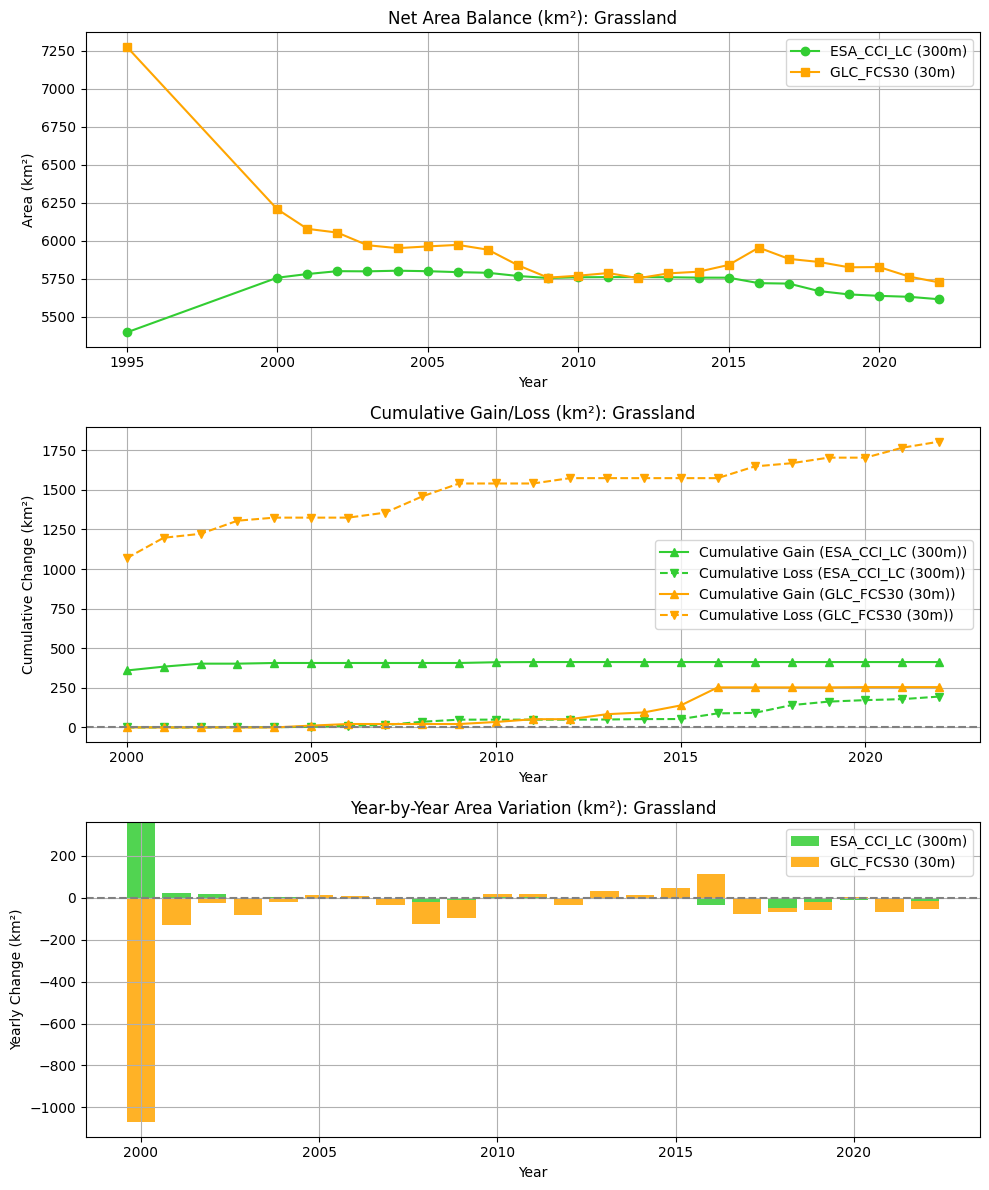

In [6]:
# --- Example usage single class---
plot_land_cover_changes_compare(
    class_name="Grassland",  # Class name to compare
    df1=df1,              # First dataset
    df2=df2,              # Second dataset
    start_year=1995,      # Start year for comparison
    end_year=2022,         # End year for comparison
    label1="ESA_CCI_LC (300m)", 
    label2="GLC_FCS30 (30m)"
)

#### PLOT SUMMARY AREA CHANGES FOR MULTIPLE CLASSES FOR EACH DATASET

In [7]:
def summarize_land_cover_changes_compare(classes, df1, df2, start_year=1992, end_year=2022, label1="Dataset 1", label2="Dataset 2"):
    years1 = df1.columns[2:].astype(int)
    years2 = df2.columns[2:].astype(int)
    common_years = sorted(set(years1).intersection(set(years2)))
    common_years = [year for year in common_years if start_year <= year <= end_year]

    if len(common_years) == 0:
        return "No overlapping years in the provided range."

    summaries = []

    for class_name in classes:
        row1 = df1[df1['Land cover class'] == class_name]
        row2 = df2[df2['Land cover class'] == class_name]
        if row1.empty or row2.empty:
            summaries.append(f"Class '{class_name}' not found in one or both datasets.")
            continue

        area1 = row1.iloc[0, 2:].values
        area2 = row2.iloc[0, 2:].values
        year_idx1 = years1.get_indexer_for(common_years)
        year_idx2 = years2.get_indexer_for(common_years)
        
        selected_area1 = area1[year_idx1]
        selected_area2 = area2[year_idx2]

        yearly_diff1 = np.diff(selected_area1)
        yearly_diff2 = np.diff(selected_area2)
        cumulative_gain1 = np.sum(np.where(yearly_diff1 > 0, yearly_diff1, 0))
        cumulative_loss1 = np.sum(np.where(yearly_diff1 < 0, -yearly_diff1, 0))
        cumulative_gain2 = np.sum(np.where(yearly_diff2 > 0, yearly_diff2, 0))
        cumulative_loss2 = np.sum(np.where(yearly_diff2 < 0, -yearly_diff2, 0))

        net_balance1 = cumulative_gain1 - cumulative_loss1
        net_balance2 = cumulative_gain2 - cumulative_loss2

        summary = {
            "Class": class_name,
            "Start Year": start_year,
            "End Year": end_year,
            f"Cumulative Gain (km²) - {label1}": round(cumulative_gain1, 2),
            f"Cumulative Loss (km²) - {label1}": round(cumulative_loss1, 2),
            f"Net Balance (km²) - {label1}": round(net_balance1, 2),
            f"Cumulative Gain (km²) - {label2}": round(cumulative_gain2, 2),
            f"Cumulative Loss (km²) - {label2}": round(cumulative_loss2, 2),
            f"Net Balance (km²) - {label2}": round(net_balance2, 2)
        }

        summaries.append(summary)

    for summary in summaries:
        if isinstance(summary, dict):
            print(f"Summary of Area Change for '{summary['Class']}' ({start_year}-{end_year}):")
            for k, v in summary.items():
                if k != 'Class':
                    print(f"  {k}: {v}")
        else:
            print(summary)

In [8]:
# --- Example usage ---
classes_to_summarize = ["Forest", "Shrubland"]
summarize_land_cover_changes_compare(
    classes=classes_to_summarize,  # List of classes to summarize
    df1=df1,                      # First dataset
    df2=df2,                      # Second dataset
    start_year=1995,              # Start year for comparison
    end_year=1996,                # End year for comparison
    label1="ESA_CCI_LC (300m)", 
    label2="GLC_FCS30 (30m)"
)

Summary of Area Change for 'Forest' (1995-1996):
  Start Year: 1995
  End Year: 1996
  Cumulative Gain (km²) - ESA_CCI_LC (300m): 0
  Cumulative Loss (km²) - ESA_CCI_LC (300m): 0
  Net Balance (km²) - ESA_CCI_LC (300m): 0
  Cumulative Gain (km²) - GLC_FCS30 (30m): 0
  Cumulative Loss (km²) - GLC_FCS30 (30m): 0
  Net Balance (km²) - GLC_FCS30 (30m): 0
Summary of Area Change for 'Shrubland' (1995-1996):
  Start Year: 1995
  End Year: 1996
  Cumulative Gain (km²) - ESA_CCI_LC (300m): 0
  Cumulative Loss (km²) - ESA_CCI_LC (300m): 0
  Net Balance (km²) - ESA_CCI_LC (300m): 0
  Cumulative Gain (km²) - GLC_FCS30 (30m): 0
  Cumulative Loss (km²) - GLC_FCS30 (30m): 0
  Net Balance (km²) - GLC_FCS30 (30m): 0
